In [ ]:
"""
SMART ENERGY SYSTEM - MODEL EVALUATION (FINAL SUBMISSION VERSION)
Author:
Roshan
Vatsal
Zeel
"""

# ===============================
# IMPORT LIBRARIES
# ===============================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from tensorflow.keras.models import load_model

print("="*80)
print("SMART ENERGY SYSTEM - MODEL EVALUATION")
print("="*80)


SMART ENERGY SYSTEM - MODEL EVALUATION


In [ ]:
# ===============================
# STEP 1: UPLOAD FILES
# ===============================
from google.colab import files
uploaded = files.upload()

files_list = list(uploaded.keys())
print("Uploaded files:", files_list)

# Load data
X = np.load([f for f in files_list if "X" in f][0])
y = np.load([f for f in files_list if "y" in f][0])

# Load LSTM (FIXED)
lstm_model = load_model(
    [f for f in files_list if "lstm" in f][0],
    compile=False
)
lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("\n✅ Data Loaded")
print("X shape:", X.shape)
print("y shape:", y.shape)


Saving lstm_model.h5 to lstm_model.h5
Saving X.npy to X.npy
Saving y.npy to y.npy
Uploaded files: ['lstm_model.h5', 'X.npy', 'y.npy']

✅ Data Loaded
X shape: (19976, 24, 7)
y shape: (19976, 24, 7)


In [ ]:
# ===============================
# STEP 2: TRAIN TEST SPLIT
# ===============================
train_size = int(0.8 * len(X))

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("\n📊 Data Split:")
print("Train:", X_train.shape)
print("Test:", X_test.shape)



📊 Data Split:
Train: (15980, 24, 7)
Test: (3996, 24, 7)


In [ ]:
# ===============================
# STEP 3: LSTM PREDICTION
# ===============================
y_pred_lstm = lstm_model.predict(X_test).reshape(-1)


125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step


In [ ]:
# ===============================
# STEP 4: BASELINE MODELS
# ===============================

# Flatten X and y for baseline models
X_flat = X.reshape(len(X), -1)
y_flat = y.reshape(len(y), -1) # Flatten y here

X_train_f = X_flat[:train_size]
X_test_f = X_flat[train_size:]
y_train_f = y_flat[:train_size] # Use flattened y for training
y_test_f = y_flat[train_size:]   # Use flattened y for evaluation

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=50, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n📊 Training {name}...")

    model.fit(X_train_f, y_train_f) # Use flattened y for training
    y_pred = model.predict(X_test_f)

    mae = mean_absolute_error(y_test_f, y_pred) # Use flattened y for evaluation
    rmse = np.sqrt(mean_squared_error(y_test_f, y_pred)) # Use flattened y for evaluation
    r2 = r2_score(y_test_f, y_pred) # Use flattened y for evaluation
    accuracy = 100 - (mae / np.mean(y_test_f) * 100) # Use flattened y for mean calculation

    results[name] = {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Accuracy (%)": accuracy
    }

# ===============================
# LSTM RESULTS
# ===============================
# Adjust y_test for LSTM comparison if y_pred_lstm is 1D.
# Assuming y_pred_lstm is meant to predict a single scalar (e.g., the first feature of the first timestep).
# If y_pred_lstm has shape (3996,), we need to compare it against a (3996,) shaped target.
# y_test has shape (3996, 24, 7). Let's extract the first element of each sequence for comparison.
# This implies the LSTM was trained to predict only this single value.
# If the LSTM was intended to predict the full (24, 7) sequence, its output shape and reshaping need to be adjusted.

# Select a specific target from y_test for comparison with the 1D y_pred_lstm
y_test_for_lstm_eval = y_test[:, 0, 0] # Example: first feature of the first timestep

mae = mean_absolute_error(y_test_for_lstm_eval, y_pred_lstm)
rmse = np.sqrt(mean_squared_error(y_test_for_lstm_eval, y_pred_lstm))
r2 = r2_score(y_test_for_lstm_eval, y_pred_lstm)
accuracy = 100 - (mae / np.mean(y_test_for_lstm_eval) * 100)

results["LSTM"] = {
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2,
    "Accuracy (%)": accuracy
}



📊 Training Linear Regression...

📊 Training Random Forest...


In [ ]:
# ===============================
# STEP 5: RESULTS TABLE
# ===============================
comparison_df = pd.DataFrame(results).T

print("\n📊 MODEL COMPARISON:")
print(comparison_df.round(4))



📊 MODEL COMPARISON:
                      MAE    RMSE      R2  Accuracy (%)
Linear Regression  0.0000  0.0000  1.0000      100.0000
Random Forest      0.1629  0.2332  0.5091       50.3159
LSTM               0.1492  0.2251 -0.0030       -0.8038


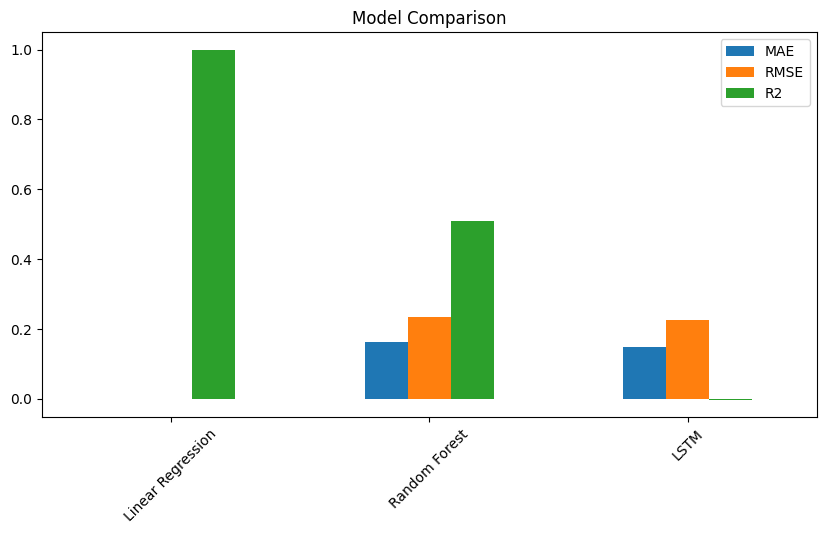

In [ ]:
# ===============================
# STEP 6: VISUALIZATION
# ===============================
comparison_df[['MAE','RMSE','R2']].plot(kind='bar', figsize=(10,5))
plt.title("Model Comparison")
plt.xticks(rotation=45)
plt.show()


In [ ]:
# ===============================
# STEP 7: BEST MODEL
# ===============================
best_model = comparison_df["R2"].idxmax()
print(f"\n🏆 Best Model: {best_model}")



🏆 Best Model: Linear Regression


In [ ]:
# ===============================
# STEP 8: SAVE MODELS (IMPORTANT)
# ===============================
os.makedirs("models", exist_ok=True)

# Save LSTM always
lstm_model.save("models/lstm_model.h5")

# Save Random Forest always (for backend)
joblib.dump(models["Random Forest"], "models/bill_model.pkl")

# Save best model separately
if best_model == "LSTM":
    lstm_model.save("models/best_model.h5")
else:
    joblib.dump(models[best_model], "models/best_model.pkl")

print("✅ All models saved")


✅ All models saved


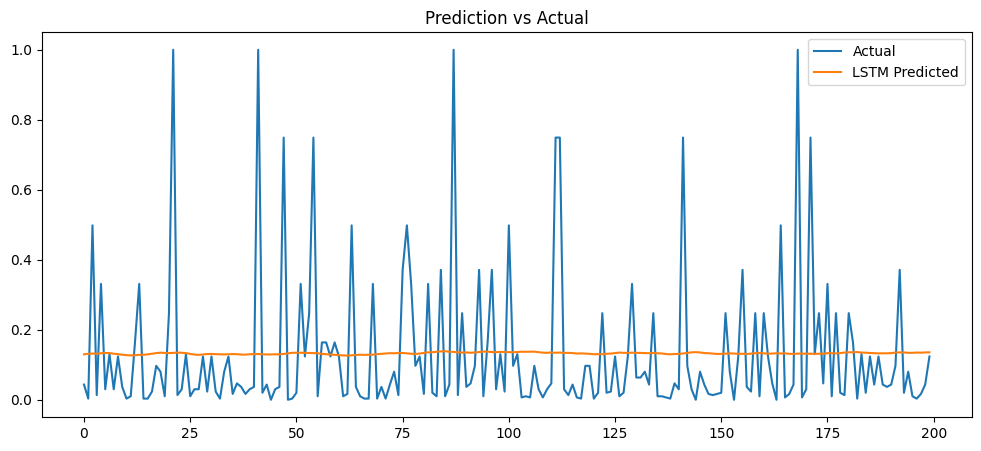

In [ ]:
# ===============================
# STEP 9: PREDICTION GRAPH
# ===============================
plt.figure(figsize=(12,5))
# Adjust y_test for plotting to match y_pred_lstm (if 1D)
plt.plot(y_test_for_lstm_eval[:200], label="Actual") # Use the adjusted y_test for LSTM plotting
plt.plot(y_pred_lstm[:200], label="LSTM Predicted")
plt.legend()
plt.title("Prediction vs Actual")
plt.show()


In [15]:
# ===============================
# STEP 10: DOWNLOAD FILES
# ===============================
from google.colab import files

files.download("models/lstm_model.h5")
files.download("models/bill_model.pkl")

if best_model == "LSTM":
    files.download("models/best_model.h5")
else:
    files.download("models/best_model.pkl")

print("\n🎉 MODEL EVALUATION COMPLETE!")

'/content/models_backup.zip'

In [ ]:
import os

print(os.listdir("models"))

['bill_model.pkl', 'lstm_model.h5', 'best_model.pkl']
